## Imports

In [1]:
#The imports 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm.auto import tqdm
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter
from IPython.display import display
from scipy.stats import mstats
import joblib
import os
import shap
import joblib
from sklearn.model_selection import learning_curve
import warnings

## EDA

In [2]:
edge_df = pd.read_csv(r"D:\agriculture_dataset.csv")
edge_df.drop(columns=['High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images', 
                      'Temporal_Images', 'Spatial_Resolution', 'GPS_Coordinates', 'Pest_Hotspots',
                      'Weed_Coverage', 'Pest_Damage', 'Expected_Yield', 'Ground_Truth_Segmentation',
                      'Bounding_Boxes', 'Drainage_Features', 'Field_Boundaries', 'Elevation_Data',
                      'Canopy_Coverage', 'Leaf_Area_Index', 'Crop_Growth_Stage', 'Crop_Stress_Indicator',
                      'NDVI', 'SAVI', 'Organic_Matter'], inplace=True)
crop_mapping = {'Wheat': 0, 'Rice': 1, 'Maize': 2}
edge_df['crop_type_enc'] = edge_df['Crop_Type'].map(crop_mapping)
edge_df = edge_df.drop(columns=['Crop_Type'])

print(edge_df.head())
print(edge_df.info())
print(edge_df.isna().sum())

   Chlorophyll_Content  Temperature   Humidity   Rainfall  Wind_Speed  \
0             0.829063    24.627325  47.240283   7.056089    2.795500   
1             0.435861    27.671999  44.408156  14.005230    2.325063   
2             1.001452    23.515820  56.268020  46.152684    1.705493   
3             0.962720    11.473797  38.637011  15.168736    5.891225   
4             2.111205    22.502605  64.438963   9.492281    2.281165   

   Soil_Moisture   Soil_pH  Water_Flow  Crop_Health_Label  crop_type_enc  
0      31.010549  6.085810   41.771884                  1              0  
1      12.429003  6.776880   27.564635                  1              0  
2      28.454713  6.078783   29.510836                  1              2  
3      28.450994  6.596315   34.822855                  0              2  
4       8.295005  7.664008   15.493255                  0              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212019 entries, 0 to 212018
Data columns (total 10 columns):


In [ ]:
print(edge_df.nunique())

Chlorophyll_Content    212019
Temperature            212019
Humidity               212019
Rainfall               212019
Wind_Speed             212019
Soil_Moisture          212019
Soil_pH                212019
Water_Flow             212019
Crop_Health_Label           2
crop_type_enc               3
dtype: int64


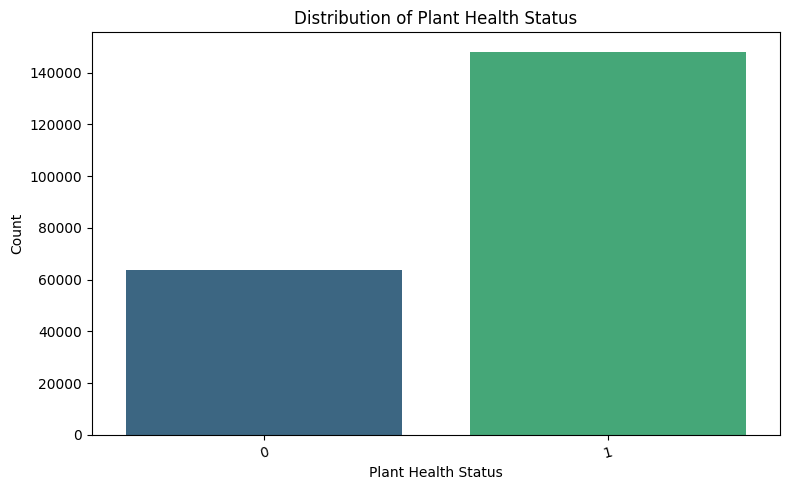

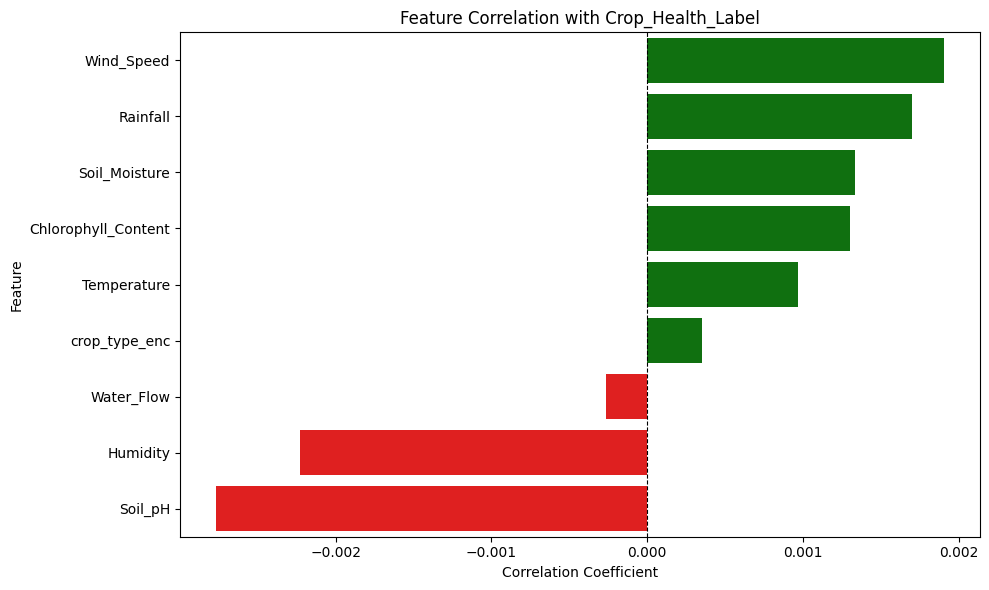

Outliers per Feature (sorted by highest %):


,Outlier Count,Percentage
Rainfall,10198,4.81
Wind_Speed,6674,3.15
Chlorophyll_Content,6622,3.12
Soil_pH,1492,0.70
Temperature,1449,0.68
Humidity,0,0.00
Soil_Moisture,0,0.00
Water_Flow,0,0.00
Crop_Health_Label,0,0.00
crop_type_enc,0,0.00


In [ ]:
warnings.filterwarnings('ignore')
target_col = "Crop_Health_Label" if "Crop_Health_Label" in edge_df.columns else None

# Visualize the distribution of the target variable
plt.figure(figsize=(8, 5))
ax_status = sns.countplot(
    data = edge_df, 
    x = target_col,
    palette = "viridis"
)
plt.title("Distribution of Plant Health Status")
plt.xlabel("Plant Health Status")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Encode target variable - use LabelEncoder to handle all actual class values

# Correlation with target variable
corr_with_target = edge_df.corr(numeric_only=True)['Crop_Health_Label'].drop('Crop_Health_Label').sort_values(ascending=False)

# Bar chart for correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors)
plt.title("Feature Correlation with Crop_Health_Label")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    return outliers

numeric_cols = edge_df.select_dtypes(include=[np.number]).columns.tolist()
outlier_counts = {col: count_outliers(edge_df, col) for col in numeric_cols}
outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
outlier_df['Percentage'] = (outlier_df['Outlier Count'] / len(edge_df) * 100).round(2)
outlier_df = outlier_df.sort_values('Percentage', ascending=False)
print("Outliers per Feature (sorted by highest %):")
display(outlier_df)


Analyzing distributions:   0%|          | 0/10 [00:00<?, ?it/s]

FEATURE DISTRIBUTION ANALYSIS


,Feature,Skewness,Skew_Type,Shapiro_p,Is_Normal,Modality,N_Modes,Extreme_Values,Extreme_%
0,Chlorophyll_Content,1.405,Right-Skewed,0.0000,False,Unimodal,1,6622,3.12%
1,Temperature,0.003,Normal/Symmetric,0.0701,True,Unimodal,1,1449,0.68%
2,Humidity,-0.002,Normal/Symmetric,0.0000,False,Multi-modal (8 modes),8,0,0.00%
3,Rainfall,1.974,Right-Skewed,0.0000,False,Unimodal,1,10198,4.81%
4,Wind_Speed,1.412,Right-Skewed,0.0000,False,Unimodal,1,6674,3.15%
5,Soil_Moisture,-0.006,Normal/Symmetric,0.0000,False,Multi-modal (8 modes),8,0,0.00%
6,Soil_pH,-0.013,Normal/Symmetric,0.6434,True,Unimodal,1,1492,0.70%
7,Water_Flow,-0.002,Normal/Symmetric,0.0000,False,Multi-modal (8 modes),8,0,0.00%
8,Crop_Health_Label,-0.868,Left-Skewed,0.0000,False,Multi-modal (0 modes),0,0,0.00%
9,crop_type_enc,0.621,Right-Skewed,0.0000,False,Unimodal,1,0,0.00%



DISTRIBUTION SUMMARY

 Skewness Categories:
   - Normal/Symmetric: 5 features
   - Right-Skewed: 4 features
   - Left-Skewed: 1 features

 Normality (Shapiro-Wilk test, α=0.05):
   - Normal distributions: 2 features
   - Non-normal distributions: 8 features

 Modality:
   - Unimodal: 6 features
   - Multi-modal (8 modes): 3 features
   - Multi-modal (0 modes): 1 features

 Features with >5% extreme values:
   None


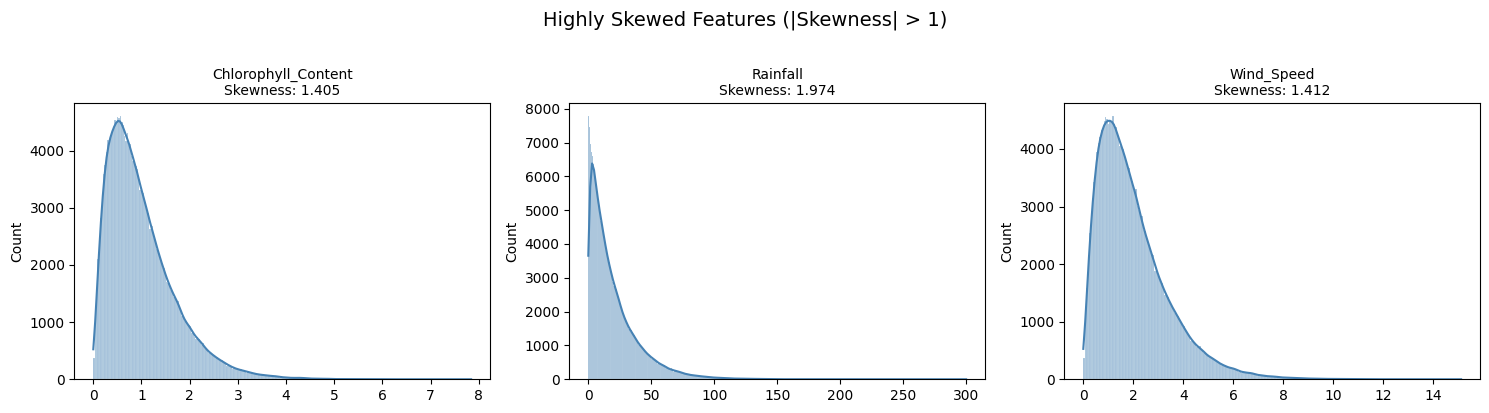

In [ ]:
# Feature Distribution Analysis: Skewness, Normality, Multi-modality, and Extreme Values
from scipy.stats import skew, kurtosis, shapiro
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

def analyze_distribution(df, col):
    """Analyze a single column's distribution characteristics."""
    data = df[col].dropna()
    
    # Skewness
    skewness = skew(data)
    if abs(skewness) < 0.5:
        skew_label = "Normal/Symmetric"
    elif skewness > 0.5:
        skew_label = "Right-Skewed"
    else:
        skew_label = "Left-Skewed"
    
    # Normality test (Shapiro-Wilk) - use sample if data is large
    sample_size = min(5000, len(data))
    sample_data = data.sample(n=sample_size, random_state=42) if len(data) > 5000 else data
    try:
        stat, p_value = shapiro(sample_data)
        is_normal = p_value > 0.05
    except Exception:
        stat, p_value = np.nan, np.nan
        is_normal = False
    
    # Multi-modality detection using KDE peak analysis
    try:
        kde = gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 200)
        kde_values = kde(x_range)
        peaks, _ = find_peaks(kde_values, height=kde_values.max() * 0.1, distance=10)
        n_modes = len(peaks)
        if n_modes == 1:
            modality = "Unimodal"
        elif n_modes == 2:
            modality = "Bimodal"
        else:
            modality = f"Multi-modal ({n_modes} modes)"
    except Exception:
        n_modes = np.nan
        modality = "Unknown"
    
    # Extreme values (IQR method)
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_extreme = ((data < lower_bound) | (data > upper_bound)).sum()
    extreme_pct = (n_extreme / len(data)) * 100
    
    return {
        "Feature": col,
        "Skewness": round(skewness, 3),
        "Skew_Type": skew_label,
        "Shapiro_p": round(p_value, 4) if not np.isnan(p_value) else np.nan,
        "Is_Normal": is_normal,
        "Modality": modality,
        "N_Modes": n_modes,
        "Extreme_Values": n_extreme,
        "Extreme_%": round(extreme_pct, 2)
    }

# Analyze all numeric columns
numeric_cols = edge_df.select_dtypes(include=[np.number]).columns.tolist()
distribution_results = [analyze_distribution(edge_df, col) for col in tqdm(numeric_cols, desc="Analyzing distributions")]
dist_df = pd.DataFrame(distribution_results)

# Display results
print("=" * 100)
print("FEATURE DISTRIBUTION ANALYSIS")
print("=" * 100)
display(dist_df.style.background_gradient(cmap='RdYlGn_r', subset=['Skewness'])
        .background_gradient(cmap='Greens', subset=['Shapiro_p'])
        .background_gradient(cmap='OrRd', subset=['Extreme_%'])
        .applymap(lambda x: 'background-color: #90EE90' if x == True else ('background-color: #FFB6C1' if x == False else ''), subset=['Is_Normal'])
        .format({'Skewness': '{:.3f}', 'Shapiro_p': '{:.4f}', 'Extreme_%': '{:.2f}%'}))

# Summary statistics
print("\n" + "=" * 100)
print("DISTRIBUTION SUMMARY")
print("=" * 100)
print(f"\n Skewness Categories:")
print(f"   - Normal/Symmetric: {(dist_df['Skew_Type'] == 'Normal/Symmetric').sum()} features")
print(f"   - Right-Skewed: {(dist_df['Skew_Type'] == 'Right-Skewed').sum()} features")
print(f"   - Left-Skewed: {(dist_df['Skew_Type'] == 'Left-Skewed').sum()} features")

print(f"\n Normality (Shapiro-Wilk test, α=0.05):")
print(f"   - Normal distributions: {dist_df['Is_Normal'].sum()} features")
print(f"   - Non-normal distributions: {(~dist_df['Is_Normal']).sum()} features")

print(f"\n Modality:")
for modality in dist_df['Modality'].unique():
    count = (dist_df['Modality'] == modality).sum()
    print(f"   - {modality}: {count} features")

print(f"\n Features with >5% extreme values:")
extreme_features = dist_df[dist_df['Extreme_%'] > 5][['Feature', 'Extreme_%', 'Extreme_Values']]
if len(extreme_features) > 0:
    display(extreme_features)
else:
    print("   None")

# Visualization: Distribution histograms with KDE for highly skewed features
skewed_features = dist_df[abs(dist_df['Skewness']) > 1]['Feature'].tolist()
if len(skewed_features) > 0:
    n_cols = 3
    n_rows = (len(skewed_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]
    
    for idx, col in enumerate(skewed_features):
        ax = axes[idx]
        sns.histplot(edge_df[col], kde=True, ax=ax, color='steelblue', edgecolor='white')
        skew_val = dist_df[dist_df['Feature'] == col]['Skewness'].values[0]
        ax.set_title(f'{col}\nSkewness: {skew_val:.3f}', fontsize=10)
        ax.set_xlabel('')
    
    # Hide empty subplots
    for idx in range(len(skewed_features), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Highly Skewed Features (|Skewness| > 1)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo highly skewed features (|Skewness| > 1) found.")

FEATURE RELATIONSHIP ANALYSIS (PAIRPLOT)

Top 5 features most correlated with Crop_Health_Label:
   1. Soil_pH: 0.0028
   2. Humidity: 0.0022
   3. Wind_Speed: 0.0019
   4. Rainfall: 0.0017
   5. Soil_Moisture: 0.0013

Generating pairplot for top 5 features...


<Figure size 640x480 with 0 Axes>

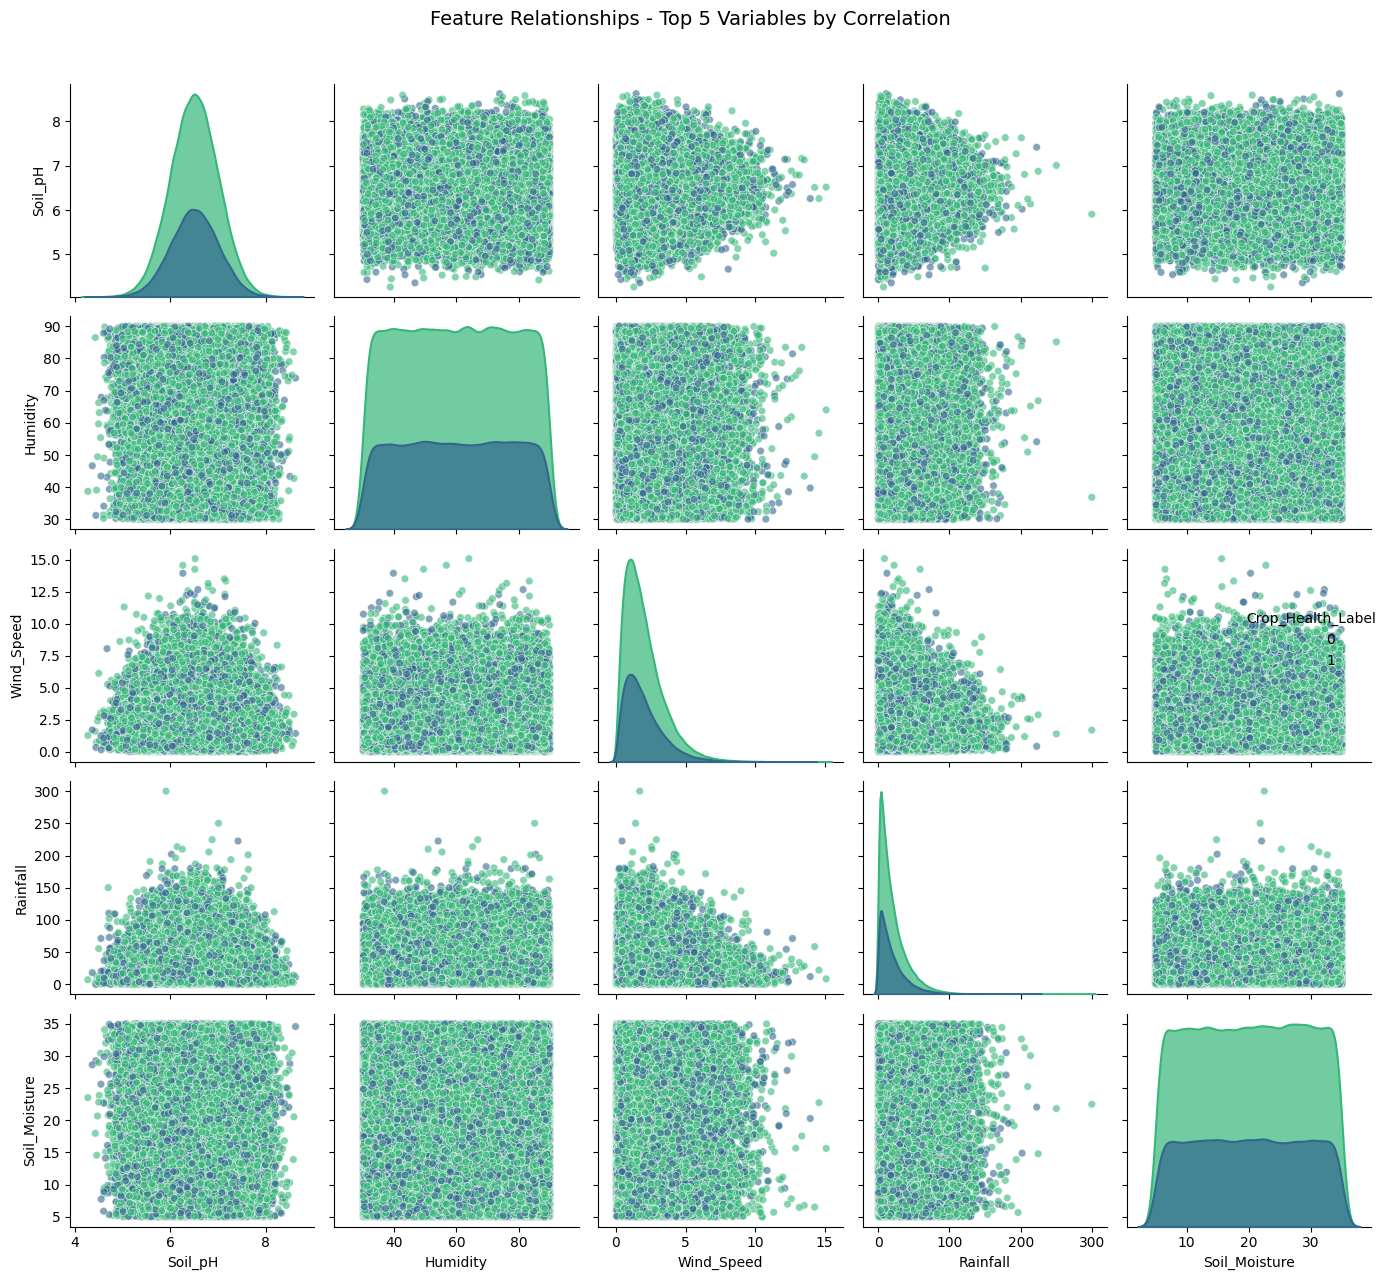


CORRELATION HEATMAP (Selected Features)


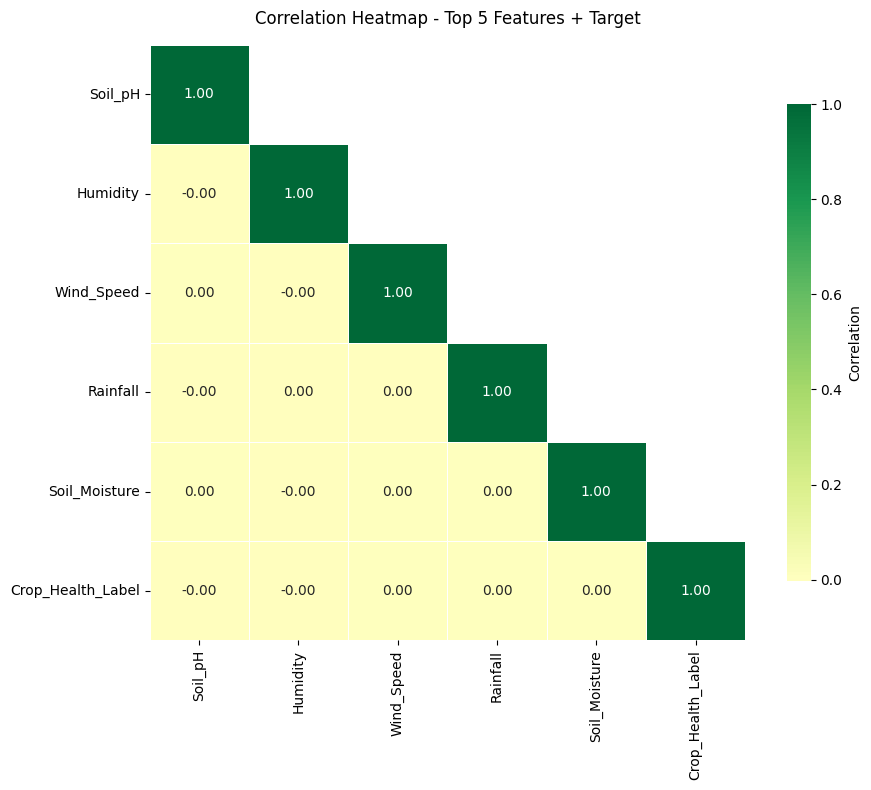


DETAILED JOINT PLOTS (Top 2 Features)


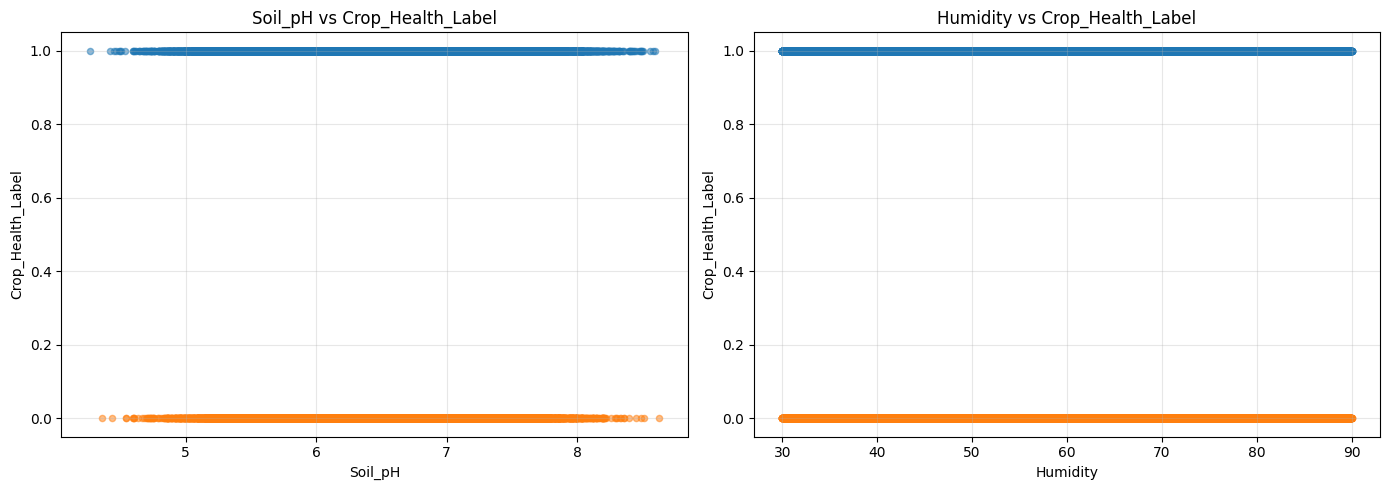

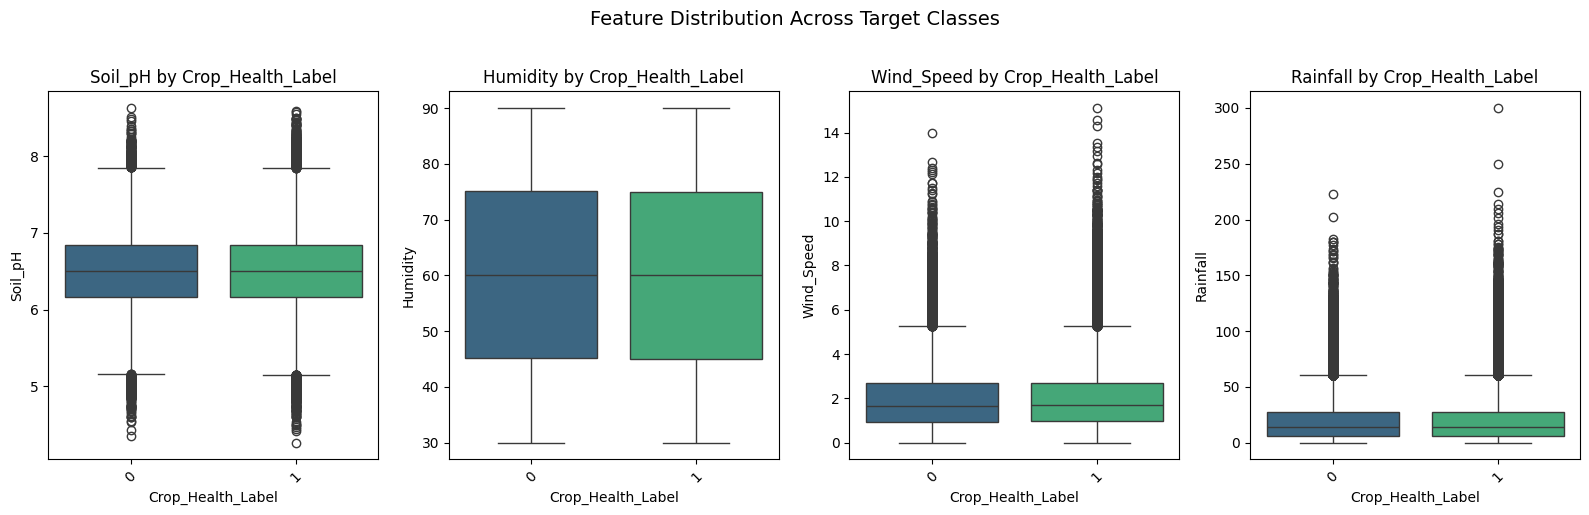


Pairplot analysis complete!


In [ ]:
# Feature Relationship Analysis - Pairplot for Important Variables
print("=" * 100)
print("FEATURE RELATIONSHIP ANALYSIS (PAIRPLOT)")
print("=" * 100)

# Select top important features based on correlation with target
target_col = "Crop_Health_Label"
corr_with_target = edge_df.corr(numeric_only=True)[target_col].drop(target_col, errors='ignore').abs().sort_values(ascending=False)

# Select top N most correlated features (limit to avoid overcrowded plot)
n_top_features = 5
top_features = corr_with_target.head(n_top_features).index.tolist()

print(f"\nTop {n_top_features} features most correlated with {target_col}:")
for i, feat in enumerate(top_features, 1):
    corr_val = corr_with_target[feat]
    print(f"   {i}. {feat}: {corr_val:.4f}")

# Create subset for pairplot
pairplot_cols = top_features + [target_col]
pairplot_df = edge_df[pairplot_cols].copy()

# Pairplot with target as hue
print(f"\nGenerating pairplot for top {n_top_features} features...")
plt.figure()
g = sns.pairplot(
    pairplot_df, 
    hue=target_col,
    palette="viridis",
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'alpha': 0.7, 'linewidth': 1.5},
    corner=False
)
g.fig.suptitle(f"Feature Relationships - Top {n_top_features} Variables by Correlation", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Correlation heatmap for the selected features
print("\n" + "=" * 100)
print("CORRELATION HEATMAP (Selected Features)")
print("=" * 100)

plt.figure(figsize=(10, 8))
corr_matrix = pairplot_df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot_kws={"size": 10}
)
plt.title(f"Correlation Heatmap - Top {n_top_features} Features + Target", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

# Additional: Joint plots for top 2 features with target
print("\n" + "=" * 100)
print("DETAILED JOINT PLOTS (Top 2 Features)")
print("=" * 100)

if len(top_features) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for idx, feat in enumerate(top_features[:2]):
        ax = axes[idx]
        for label in pairplot_df[target_col].unique():
            subset = pairplot_df[pairplot_df[target_col] == label]
            ax.scatter(subset[feat], subset[target_col], alpha=0.5, label=f'{target_col}={label}', s=20)
        ax.set_xlabel(feat)
        ax.set_ylabel(target_col)
        ax.set_title(f'{feat} vs {target_col}')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Boxplots showing distribution of top features across target classes
    fig, axes = plt.subplots(1, min(4, len(top_features)), figsize=(16, 5))
    if len(top_features) == 1:
        axes = [axes]
    
    for idx, feat in enumerate(top_features[:4]):
        ax = axes[idx] if len(top_features) > 1 else axes
        sns.boxplot(data=pairplot_df, x=target_col, y=feat, palette="viridis", ax=ax)
        ax.set_title(f'{feat} by {target_col}')
        ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle("Feature Distribution Across Target Classes", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

print("\nPairplot analysis complete!")

## Fixing Imabalnced Data

IMBALANCED DATA ANALYSIS

Original Class Distribution:
   Class 0: 63821 samples (30.1%)
   Class 1: 148198 samples (69.9%)

Imbalance Ratio (Majority/Minority): 2.32


C:\Users\evett\AppData\Local\Temp\ipykernel_11260\4016867140.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, order=class_names, palette="viridis")


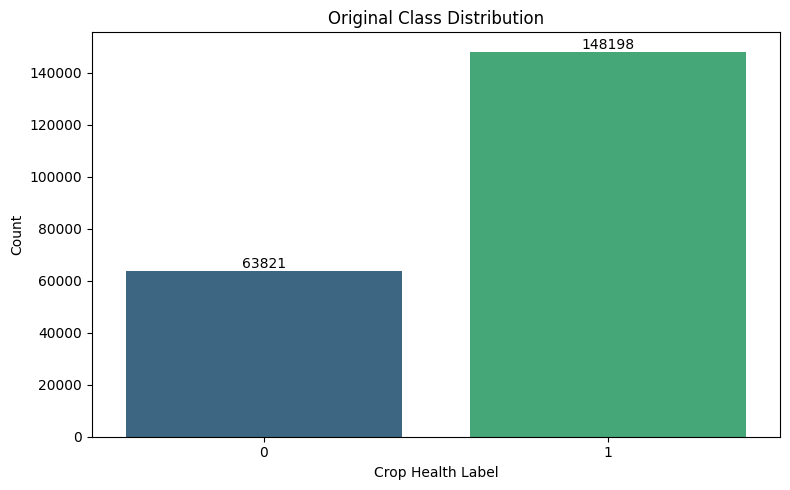

In [3]:
# Prepare features and target
X = edge_df.drop(columns=["Crop_Health_Label"], errors="ignore")
y = edge_df["Crop_Health_Label"]

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

print("=" * 80)
print("IMBALANCED DATA ANALYSIS")
print("=" * 80)

# Show original class distribution
print("\nOriginal Class Distribution:")
original_counts = Counter(y_encoded)
for cls_idx, count in sorted(original_counts.items()):
    pct = count / len(y_encoded) * 100
    print(f"   Class {class_names[cls_idx]}: {count} samples ({pct:.1f}%)")

# Calculate imbalance ratio
majority_count = max(original_counts.values())
minority_count = min(original_counts.values())
imbalance_ratio = majority_count / minority_count
print(f"\nImbalance Ratio (Majority/Minority): {imbalance_ratio:.2f}")

# Visualize original distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y, order=class_names, palette="viridis")
plt.title("Original Class Distribution")
plt.xlabel("Crop Health Label")
plt.ylabel("Count")
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Store results for comparison
resampling_results = []

In [ ]:
# Method 1: SMOTE (Synthetic Minority Over-sampling Technique)
print("=" * 80)
print("METHOD 1: SMOTE")
print("=" * 80)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y_encoded)
smote_counts = Counter(y_smote)

print(f"\nTotal samples: {len(y_smote)} (was {len(y_encoded)}, change: {len(y_smote) - len(y_encoded):+d})")
new_ratio = max(smote_counts.values()) / min(smote_counts.values())
print(f"New imbalance ratio: {new_ratio:.2f} (was {imbalance_ratio:.2f})")
for cls_idx, count in sorted(smote_counts.items()):
    print(f"   Class {class_names[cls_idx]}: {count} samples")

resampling_results.append({
    "Method": "SMOTE",
    "Total Samples": len(y_smote),
    "Change": len(y_smote) - len(y_encoded),
    "New Imbalance Ratio": round(new_ratio, 2)
})

# Visualize
plt.figure(figsize=(8, 5))
smote_classes = [class_names[i] for i in y_smote]
sns.countplot(x=smote_classes, order=class_names, palette="viridis")
plt.title("SMOTE - Balanced Class Distribution")
plt.xlabel("Crop Health Label")
plt.ylabel("Count")
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Method 2: ADASYN (Adaptive Synthetic Sampling)
print("=" * 80)
print("METHOD 2: ADASYN")
print("=" * 80)

try:
    adasyn = ADASYN(random_state=42)
    X_adasyn, y_adasyn = adasyn.fit_resample(X, y_encoded)
    adasyn_counts = Counter(y_adasyn)

    print(f"\nTotal samples: {len(y_adasyn)} (was {len(y_encoded)}, change: {len(y_adasyn) - len(y_encoded):+d})")
    new_ratio = max(adasyn_counts.values()) / min(adasyn_counts.values())
    print(f"New imbalance ratio: {new_ratio:.2f} (was {imbalance_ratio:.2f})")
    for cls_idx, count in sorted(adasyn_counts.items()):
        print(f"   Class {class_names[cls_idx]}: {count} samples")

    resampling_results.append({
        "Method": "ADASYN",
        "Total Samples": len(y_adasyn),
        "Change": len(y_adasyn) - len(y_encoded),
        "New Imbalance Ratio": round(new_ratio, 2)
    })

    # Visualize
    plt.figure(figsize=(8, 5))
    adasyn_classes = [class_names[i] for i in y_adasyn]
    sns.countplot(x=adasyn_classes, order=class_names, palette="viridis")
    plt.title("ADASYN - Balanced Class Distribution")
    plt.xlabel("Crop Health Label")
    plt.ylabel("Count")
    for p in plt.gca().patches:
        plt.gca().annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"ADASYN Failed: {str(e)}")

METHOD 2: ADASYN
ADASYN Failed: name 'X' is not defined


METHOD 3: RANDOM RESAMPLING
Target: 150000 samples per class (2 classes)
Current counts: {np.int64(1): 148198, np.int64(0): 63821}

Total samples: 300000 (was 212019, change: +87981)
New imbalance ratio: 1.00 (was 2.32)
   Class 0: 150000 samples
   Class 1: 150000 samples


C:\Users\evett\AppData\Local\Temp\ipykernel_11260\757936233.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=ros_classes, order=class_names, palette="viridis")


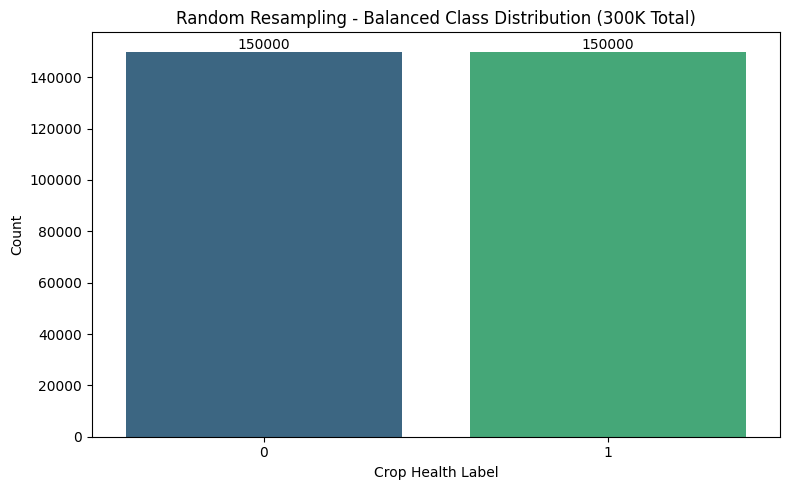

In [4]:
# Method 3: Random Sampling (Target: 300,000 total samples, balanced)
print("=" * 80)
print("METHOD 3: RANDOM RESAMPLING")
print("=" * 80)

# Calculate target samples per class for 300,000 total
n_classes = len(np.unique(y_encoded))
samples_per_class = 300000 // n_classes
print(f"Target: {samples_per_class} samples per class ({n_classes} classes)")

# Check current class counts
current_counts = Counter(y_encoded)
print(f"Current counts: {dict(current_counts)}")

# First undersample classes that are above target
undersample_strategy = {cls: min(count, samples_per_class) for cls, count in current_counts.items()}
rus = RandomUnderSampler(sampling_strategy=undersample_strategy, random_state=42)
X_temp, y_temp = rus.fit_resample(X, y_encoded)

# Then oversample classes that are below target
oversample_strategy = {cls: samples_per_class for cls in range(n_classes)}
ros = RandomOverSampler(sampling_strategy=oversample_strategy, random_state=42)
X_ros, y_ros = ros.fit_resample(X_temp, y_temp)
ros_counts = Counter(y_ros)

print(f"\nTotal samples: {len(y_ros)} (was {len(y_encoded)}, change: {len(y_ros) - len(y_encoded):+d})")
new_ratio = max(ros_counts.values()) / min(ros_counts.values())
print(f"New imbalance ratio: {new_ratio:.2f} (was {imbalance_ratio:.2f})")
for cls_idx, count in sorted(ros_counts.items()):
    print(f"   Class {class_names[cls_idx]}: {count} samples")

resampling_results.append({
    "Method": "Random Resampling",
    "Total Samples": len(y_ros),
    "Change": len(y_ros) - len(y_encoded),
    "New Imbalance Ratio": round(new_ratio, 2)
})

# Visualize
plt.figure(figsize=(8, 5))
ros_classes = [class_names[i] for i in y_ros]
sns.countplot(x=ros_classes, order=class_names, palette="viridis")
plt.title("Random Resampling - Balanced Class Distribution (300K Total)")
plt.xlabel("Crop Health Label")
plt.ylabel("Count")
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Prediction Models

Classes: ['0', '1']
Class distribution (balanced):
   0: 148198
   1: 148198
Training and evaluating models...



Model Evaluation Progress:   0%|          | 0/11 [00:00<?, ?it/s]


MODEL: Logistic Regression
Accuracy: 0.498
F1 Score: 0.498



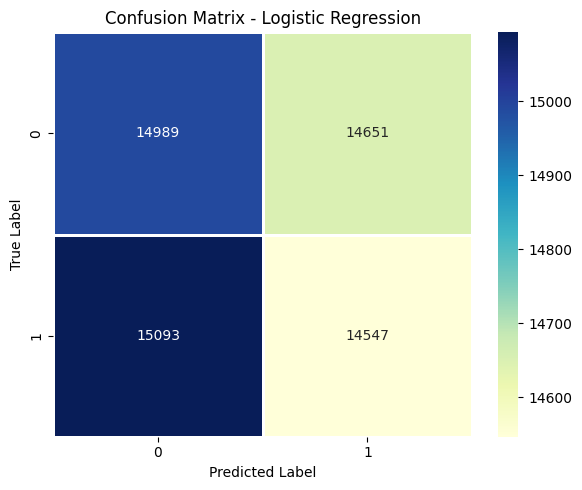

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.50      0.51      0.50     29640
           1       0.50      0.49      0.49     29640

    accuracy                           0.50     59280
   macro avg       0.50      0.50      0.50     59280
weighted avg       0.50      0.50      0.50     59280


------------------------------------------------------------------------------------------


MODEL: KNN
Accuracy: 0.606
F1 Score: 0.604



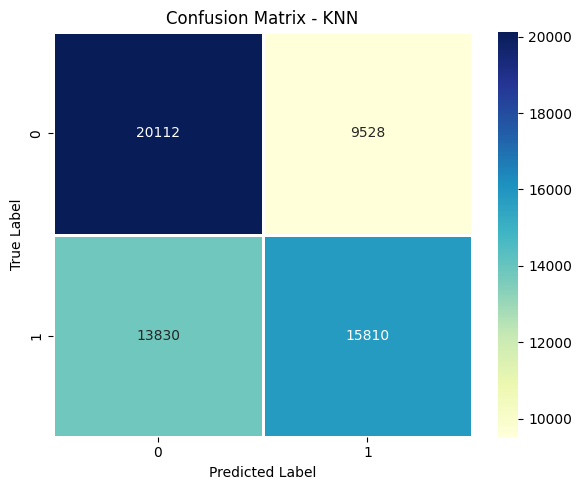

Classification Report for KNN:

              precision    recall  f1-score   support

           0       0.59      0.68      0.63     29640
           1       0.62      0.53      0.58     29640

    accuracy                           0.61     59280
   macro avg       0.61      0.61      0.60     59280
weighted avg       0.61      0.61      0.60     59280


------------------------------------------------------------------------------------------


MODEL: Decision Tree
Accuracy: 0.505
F1 Score: 0.499



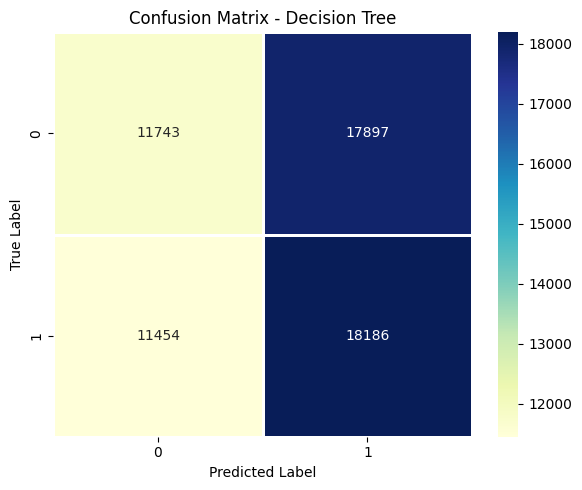

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.51      0.40      0.44     29640
           1       0.50      0.61      0.55     29640

    accuracy                           0.50     59280
   macro avg       0.51      0.50      0.50     59280
weighted avg       0.51      0.50      0.50     59280


------------------------------------------------------------------------------------------


MODEL: Random Forest
Accuracy: 0.947
F1 Score: 0.947



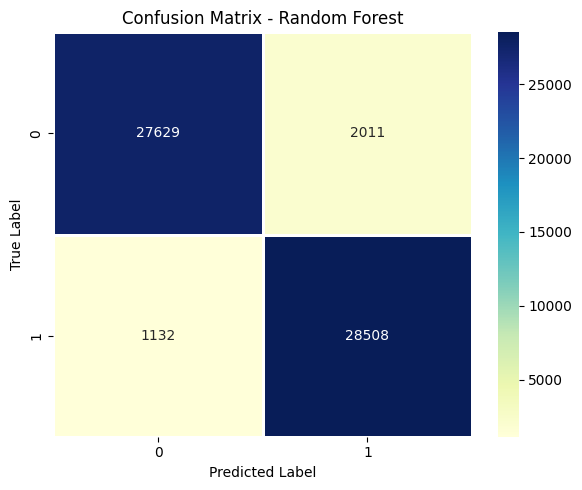

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.96      0.93      0.95     29640
           1       0.93      0.96      0.95     29640

    accuracy                           0.95     59280
   macro avg       0.95      0.95      0.95     59280
weighted avg       0.95      0.95      0.95     59280


------------------------------------------------------------------------------------------


MODEL: Gradient Boosting
Accuracy: 0.514
F1 Score: 0.513



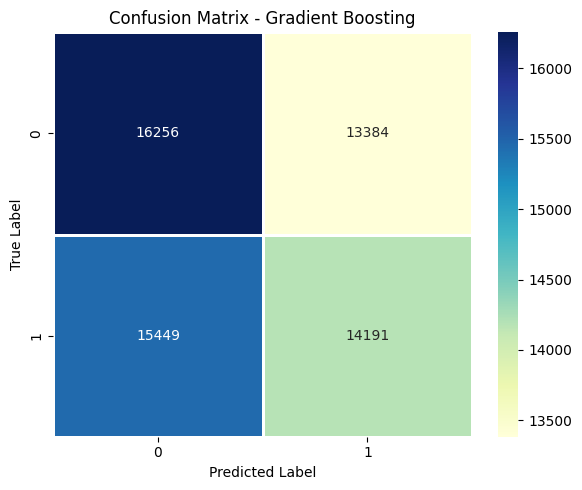

Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.51      0.55      0.53     29640
           1       0.51      0.48      0.50     29640

    accuracy                           0.51     59280
   macro avg       0.51      0.51      0.51     59280
weighted avg       0.51      0.51      0.51     59280


------------------------------------------------------------------------------------------


MODEL: AdaBoost
Accuracy: 0.499
F1 Score: 0.483



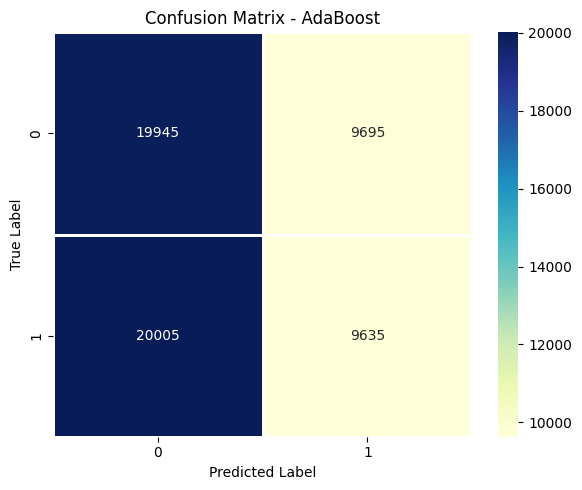

Classification Report for AdaBoost:

              precision    recall  f1-score   support

           0       0.50      0.67      0.57     29640
           1       0.50      0.33      0.39     29640

    accuracy                           0.50     59280
   macro avg       0.50      0.50      0.48     59280
weighted avg       0.50      0.50      0.48     59280


------------------------------------------------------------------------------------------


MODEL: Extra Trees
Accuracy: 0.962
F1 Score: 0.962



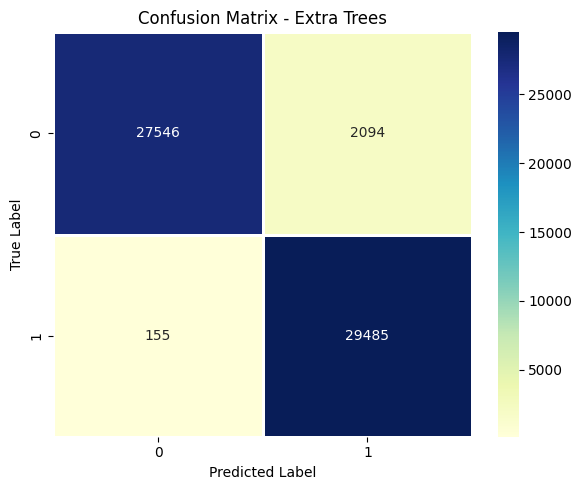

Classification Report for Extra Trees:

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     29640
           1       0.93      0.99      0.96     29640

    accuracy                           0.96     59280
   macro avg       0.96      0.96      0.96     59280
weighted avg       0.96      0.96      0.96     59280


------------------------------------------------------------------------------------------


MODEL: Gaussian NB
Accuracy: 0.500
F1 Score: 0.496



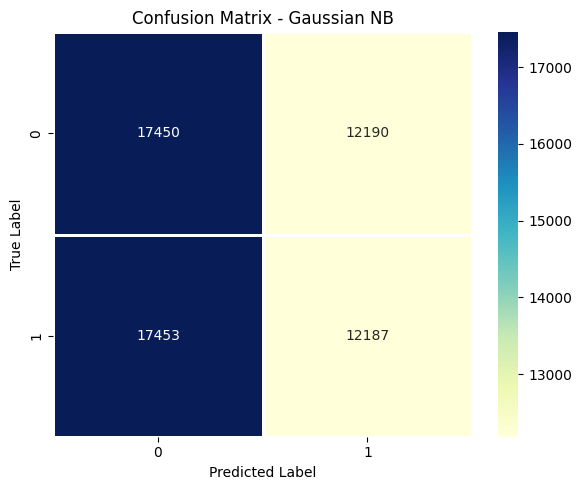

Classification Report for Gaussian NB:

              precision    recall  f1-score   support

           0       0.50      0.59      0.54     29640
           1       0.50      0.41      0.45     29640

    accuracy                           0.50     59280
   macro avg       0.50      0.50      0.50     59280
weighted avg       0.50      0.50      0.50     59280


------------------------------------------------------------------------------------------


MODEL: XGBoost
Accuracy: 0.578
F1 Score: 0.578



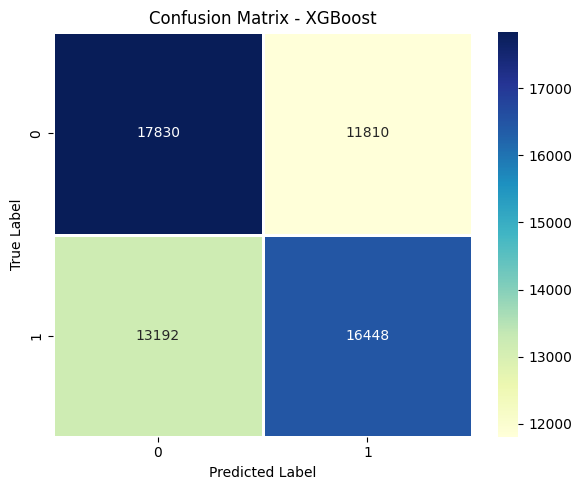

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.57      0.60      0.59     29640
           1       0.58      0.55      0.57     29640

    accuracy                           0.58     59280
   macro avg       0.58      0.58      0.58     59280
weighted avg       0.58      0.58      0.58     59280


------------------------------------------------------------------------------------------



C:\Users\evett\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\evett\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



MODEL: LightGBM
Accuracy: 0.549
F1 Score: 0.548



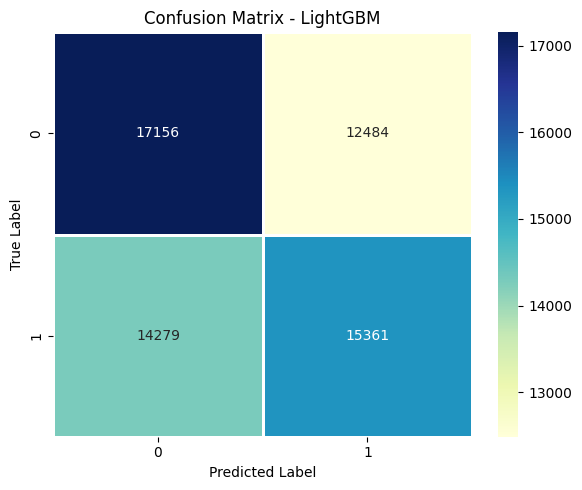

Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.55      0.58      0.56     29640
           1       0.55      0.52      0.53     29640

    accuracy                           0.55     59280
   macro avg       0.55      0.55      0.55     59280
weighted avg       0.55      0.55      0.55     59280


------------------------------------------------------------------------------------------


MODEL: CatBoost
Accuracy: 0.581
F1 Score: 0.581



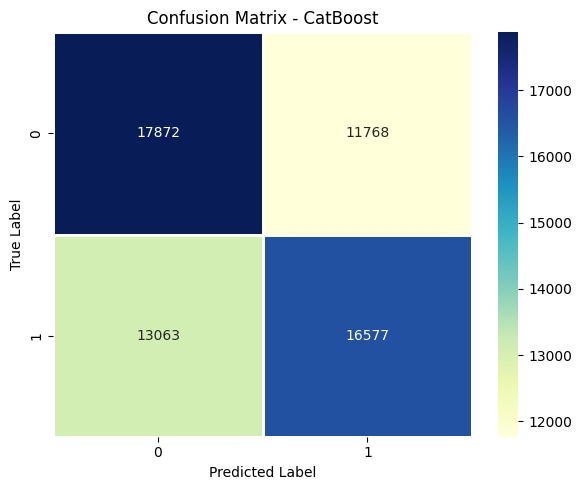

Classification Report for CatBoost:

              precision    recall  f1-score   support

           0       0.58      0.60      0.59     29640
           1       0.58      0.56      0.57     29640

    accuracy                           0.58     59280
   macro avg       0.58      0.58      0.58     59280
weighted avg       0.58      0.58      0.58     59280


------------------------------------------------------------------------------------------


Overall model performance summary:



C:\Users\evett\AppData\Roaming\Python\Python314\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
C:\Users\evett\AppData\Roaming\Python\Python314\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Model,Accuracy,F1_Score,AUC
0,Extra Trees,0.962,0.962,nan
1,Random Forest,0.947,0.947,nan
2,KNN,0.606,0.604,nan
3,CatBoost,0.581,0.581,nan
4,XGBoost,0.578,0.578,nan
5,LightGBM,0.549,0.548,nan
6,Gradient Boosting,0.514,0.513,nan
7,Decision Tree,0.505,0.499,nan
8,Gaussian NB,0.500,0.496,nan
9,AdaBoost,0.499,0.483,nan


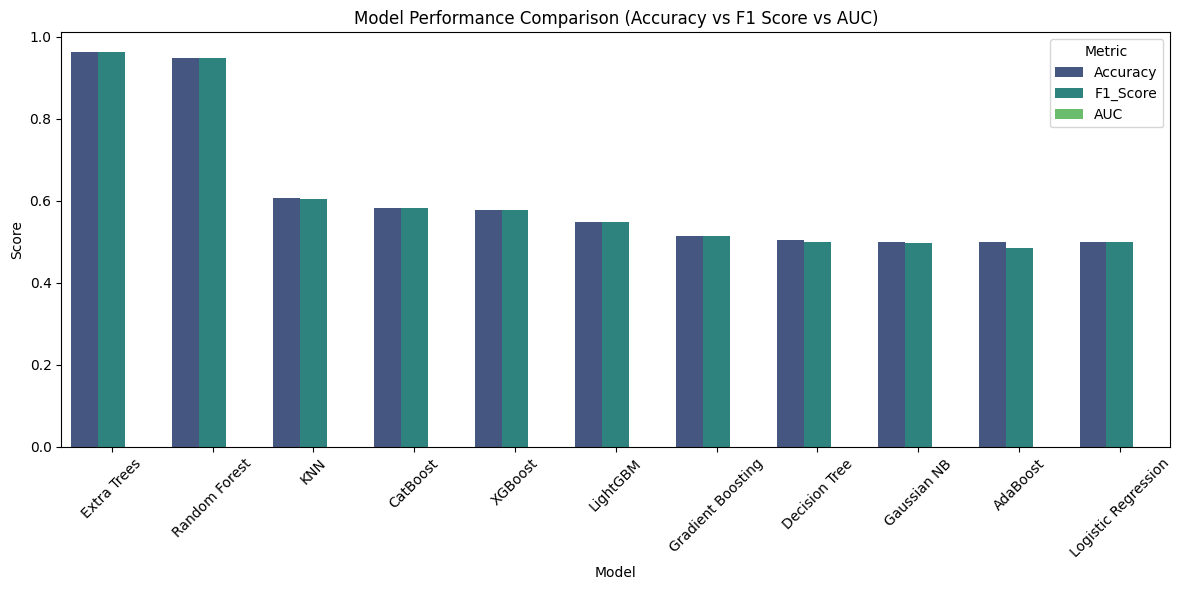


Best model selected: Extra Trees
Accuracy: 0.962
F1 Score: 0.962


C:\Users\evett\AppData\Local\Temp\ipykernel_16920\4101658130.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred_best, order=range(len(class_names_str)), palette="YlGnBu")


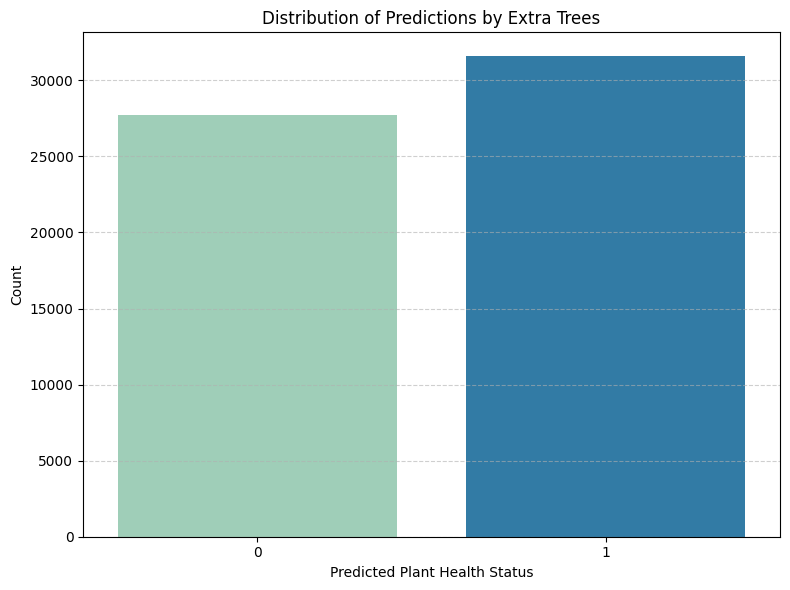

In [ ]:
X = X_ros
y = y_ros

# Get class names from label encoder
class_names_str = [str(c) for c in class_names]
print(f"Classes: {class_names_str}")
print(f"Class distribution (balanced):")
for i, name in enumerate(class_names):
    count = (y == i).sum()
    print(f"   {name}: {count}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaled versions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=8),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "Gaussian NB": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

results_list = []
print("Training and evaluating models...\n")

for model_name, model_candidate in tqdm(models.items(), desc="Model Evaluation Progress"):
    model_candidate.fit(X_train_scaled, y_train)
    y_pred_model = model_candidate.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_model)
    f1 = f1_score(y_test, y_pred_model, average='weighted')

    try:
        y_prob = model_candidate.predict_proba(X_test_scaled)
        auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
    except Exception:
        auc = np.nan

    results_list.append({
        "Model": model_name,
        "Model_Object": model_candidate,
        "Accuracy": accuracy,
        "F1_Score": f1,
        "AUC": auc
    })

    print("\n" + "=" * 90)
    print(f"MODEL: {model_name}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"F1 Score: {f1:.3f}")
    if not np.isnan(auc):
        print(f"AUC Score: {auc:.3f}")
    print("=" * 90 + "\n")

    cm = confusion_matrix(y_test, y_pred_model)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        linewidths=0.8,
        xticklabels=class_names_str,
        yticklabels=class_names_str
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    print(f"Classification Report for {model_name}:\n")
    print(
        classification_report(
            y_test,
            y_pred_model,
            target_names=class_names_str,
            zero_division=0
        )
    )
    print("\n" + "-" * 90 + "\n")

results_df = pd.DataFrame(results_list)
results_df["AUC_sort"] = results_df["AUC"].fillna(-1)
results_df = results_df.sort_values(["Accuracy", "F1_Score", "AUC_sort"], ascending=False).drop(columns=["AUC_sort"]).reset_index(drop=True)

print("\nOverall model performance summary:\n")
display(
    results_df[["Model", "Accuracy", "F1_Score", "AUC"]]
    .style.background_gradient(cmap="Greens", subset=["Accuracy", "F1_Score", "AUC"])
    .format({"Accuracy": "{:.3f}", "F1_Score": "{:.3f}", "AUC": "{:.3f}"})
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "12pt"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center"), ("font-size", "11pt")]}
    ])
)

plt.figure(figsize=(12, 6))
plot_df = results_df[["Model", "Accuracy", "F1_Score", "AUC"]].melt(id_vars="Model", value_vars=["Accuracy", "F1_Score", "AUC"])
sns.barplot(data=plot_df, x="Model", y="value", hue="variable", palette="viridis")
plt.title("Model Performance Comparison (Accuracy vs F1 Score vs AUC)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_model_data = results_df.iloc[0]
best_model_name = best_model_data["Model"]
best_model = best_model_data["Model_Object"]
best_accuracy = best_model_data["Accuracy"]
best_f1 = best_model_data["F1_Score"]
best_auc = best_model_data["AUC"]

print(f"\nBest model selected: {best_model_name}")
print(f"Accuracy: {best_accuracy:.3f}")
print(f"F1 Score: {best_f1:.3f}")
if not np.isnan(best_auc):
    print(f"AUC: {best_auc:.3f}")

# Use best model for downstream cells
y_pred_best = best_model.predict(X_test_scaled)
model = best_model
y_pred = y_pred_best

plt.figure(figsize=(8, 6))
sns.countplot(x=y_pred_best, order=range(len(class_names_str)), palette="YlGnBu")
plt.xticks(range(len(class_names_str)), class_names_str)
plt.xlabel("Predicted Plant Health Status")
plt.ylabel("Count")
plt.title(f"Distribution of Predictions by {best_model_name}")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## for SHAP

Classes: ['0', '1']
Class distribution (balanced):
   0: 150000
   1: 150000

Training best model (classifier) on the entire training set... Done!
Model Storage Size: 361.77 MB

MODEL EVALUATION SUMMARY

Accuracy:  0.8880
F1 Score:  0.8878
Recall:    0.8880
Precision: 0.8897
Storage:   361.77 MB

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     30000
           1       0.92      0.85      0.88     30000

    accuracy                           0.89     60000
   macro avg       0.89      0.89      0.89     60000
weighted avg       0.89      0.89      0.89     60000


CONFUSION MATRIX


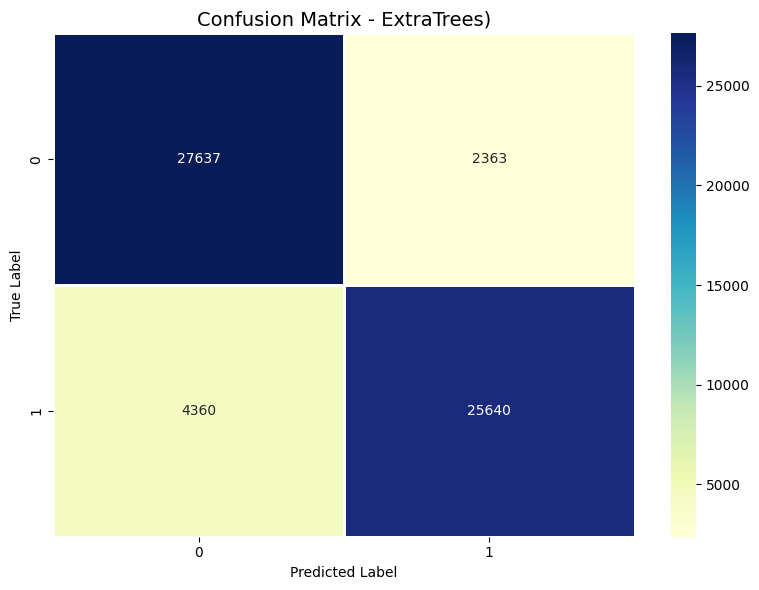


METRICS SUMMARY TABLE


,Metric,Value
0,Accuracy,0.8880
1,F1 Score,0.8878
2,Recall,0.8880
3,Precision,0.8897
4,Storage (MB),361.7706


In [11]:
# Get class names from label encoder
class_names_str = [str(c) for c in class_names]
print(f"Classes: {class_names_str}")
print(f"Class distribution (balanced):")
for i, name in enumerate(class_names):
    count = (y == i).sum()
    print(f"   {name}: {count}")

X = X_ros
y = y_ros

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaled versions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model = ExtraTreesClassifier(n_estimators=150, random_state=42, n_jobs=-1, max_depth=20)
best_model.fit(X_train_scaled, y_train)

# Use best model for downstream cells
y_pred_best = best_model.predict(X_test_scaled)
model = best_model
y_pred = y_pred_best

# Calculate model storage size
import io
buffer = io.BytesIO()
joblib.dump(model, buffer)
model_size_mb = buffer.tell() / (1024 * 1024)

print(f"\nTraining best model ({best_model._estimator_type}) on the entire training set... Done!")
print(f"Model Storage Size: {model_size_mb:.2f} MB")

# ============ MODEL EVALUATION ============
print("\n" + "=" * 80)
print("MODEL EVALUATION SUMMARY")
print("=" * 80)

# Calculate metrics
from sklearn.metrics import recall_score, precision_score

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

try:
    y_prob = model.predict_proba(X_test_scaled)
    auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
except Exception:
    auc = np.nan

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
if not np.isnan(auc):
    print(f"AUC:       {auc:.4f}")
print(f"Storage:   {model_size_mb:.2f} MB")

# Classification Report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=class_names_str, zero_division=0))

# Confusion Matrix
print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.8,
    xticklabels=class_names_str,
    yticklabels=class_names_str
)
plt.title(f"Confusion Matrix - ExtraTrees)", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 80)
print("METRICS SUMMARY TABLE")
print("=" * 80)
summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "Recall", "Precision", "Storage (MB)"],
    "Value": [accuracy, f1, recall, precision, model_size_mb]
})
display(summary_df.style.format({"Value": "{:.4f}"}).background_gradient(cmap="Greens", subset=["Value"]))

## Accuracy vs Storage

HYPERPARAMETER GRID SEARCH: ExtraTrees Classifier
Testing all combinations of n_estimators and max_depth

Testing 20 combinations...
--------------------------------------------------------------------------------


n_estimators:   0%|          | 0/4 [00:00<?, ?it/s]

  n_est=100, depth=15   : Acc=0.7115, F1=0.7109, Size≈129.1MB, Time=6.4s
  n_est=100, depth=20   : Acc=0.8743, F1=0.8740, Size≈601.2MB, Time=7.8s
  n_est=100, depth=25   : Acc=0.9369, F1=0.9369, Size≈1604.7MB, Time=8.7s
  n_est=100, depth=30   : Acc=0.9537, F1=0.9537, Size≈2713.6MB, Time=9.7s
  n_est=100, depth=None : Acc=0.9571, F1=0.9571, Size≈3793.9MB, Time=10.5s
  n_est=150, depth=15   : Acc=0.7243, F1=0.7237, Size≈192.7MB, Time=9.2s
  n_est=150, depth=20   : Acc=0.8880, F1=0.8878, Size≈904.3MB, Time=11.5s
  n_est=150, depth=25   : Acc=0.9435, F1=0.9435, Size≈2392.0MB, Time=12.9s
  n_est=150, depth=30   : Acc=0.9580, F1=0.9580, Size≈4088.2MB, Time=15.4s
  n_est=150, depth=None : Acc=0.9606, F1=0.9606, Size≈5691.4MB, Time=27.3s
  n_est=200, depth=15   : Acc=0.7301, F1=0.7296, Size≈254.1MB, Time=22.0s
  n_est=200, depth=20   : Acc=0.8939, F1=0.8938, Size≈1197.8MB, Time=30.2s
  n_est=200, depth=25   : Acc=0.9486, F1=0.9486, Size≈3205.8MB, Time=31.2s
  n_est=200, depth=30   : Acc=0.959

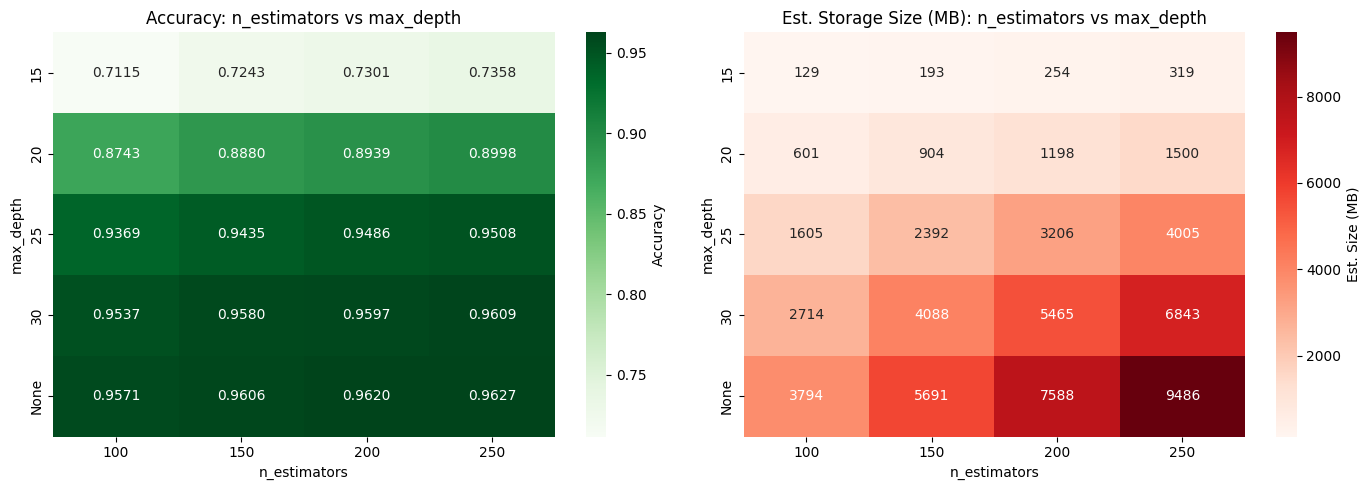


FULL GRID SEARCH RESULTS


,n_estimators,max_depth,accuracy,f1_score,size_mb,time_seconds
0,100,15,0.7115,0.7109,129.1,6.4
1,100,20,0.8743,0.8740,601.2,7.8
2,100,25,0.9369,0.9369,1604.7,8.7
3,100,30,0.9537,0.9537,2713.6,9.7
4,100,None,0.9571,0.9571,3793.9,10.5
5,150,15,0.7243,0.7237,192.7,9.2
6,150,20,0.8880,0.8878,904.3,11.5
7,150,25,0.9435,0.9435,2392.0,12.9
8,150,30,0.9580,0.9580,4088.2,15.4
9,150,None,0.9606,0.9606,5691.4,27.3


In [5]:
# ============================================================
# HYPERPARAMETER GRID SEARCH: n_estimators x max_depth
# ============================================================
print("=" * 80)
print("HYPERPARAMETER GRID SEARCH: ExtraTrees Classifier")
print("Testing all combinations of n_estimators and max_depth")
print("=" * 80)

import io
import time
import gc

def estimate_model_size_mb(model):
    """Estimate model size in MB based on tree structure (memory-efficient)"""
    try:
        total_nodes = 0
        for tree in model.estimators_:
            total_nodes += tree.tree_.node_count
        # Rough estimate: ~200 bytes per node (features, thresholds, values, etc.)
        estimated_bytes = total_nodes * 200
        return estimated_bytes / (1024 * 1024)
    except Exception:
        return np.nan

X = X_ros
y = y_ros

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaled versions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Define hyperparameter ranges
n_estimators_range = [100, 150, 200, 250]
max_depth_range = [15, 20, 25, 30, None]  # None = unlimited depth

# Store results
grid_results = []
total_combinations = len(n_estimators_range) * len(max_depth_range)
print(f"\nTesting {total_combinations} combinations...")
print("-" * 80)

# Nested loop: test every combination of n_estimators and max_depth
for n_est in tqdm(n_estimators_range, desc="n_estimators"):
    for depth in max_depth_range:
        start_time = time.time()
        
        # Train model with current hyperparameters
        if depth is None:
            clf = ExtraTreesClassifier(
                n_estimators=n_est, 
                random_state=42, 
                n_jobs=-1
            )
        else:
            clf = ExtraTreesClassifier(
                n_estimators=n_est, 
                max_depth=depth, 
                random_state=42, 
                n_jobs=-1
            )
        clf.fit(X_train_scaled, y_train)
        
        # Evaluate
        y_pred_grid = clf.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred_grid)
        f1_val = f1_score(y_test, y_pred_grid, average='weighted')
        
        # Estimate storage size (memory-efficient method)
        model_size = estimate_model_size_mb(clf)
        
        elapsed = time.time() - start_time
        depth_str = str(depth) if depth is not None else 'None'
        
        grid_results.append({
            'n_estimators': n_est,
            'max_depth': depth_str,
            'accuracy': acc,
            'f1_score': f1_val,
            'size_mb': model_size,
            'time_seconds': elapsed
        })
        
        size_str = f"{model_size:.1f}" if not np.isnan(model_size) else "N/A"
        print(f"  n_est={n_est:3d}, depth={depth_str:5s}: Acc={acc:.4f}, F1={f1_val:.4f}, Size≈{size_str}MB, Time={elapsed:.1f}s")
        
        # Clean up to free memory
        del clf
        gc.collect()

# Create results DataFrame
grid_df = pd.DataFrame(grid_results)

# Find best model by accuracy
best_row = grid_df.loc[grid_df['accuracy'].idxmax()]
print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS (by Accuracy)")
print("=" * 80)
print(f"  n_estimators: {int(best_row['n_estimators'])}")
print(f"  max_depth: {best_row['max_depth']}")
print(f"  Accuracy: {best_row['accuracy']:.4f}")
print(f"  F1 Score: {best_row['f1_score']:.4f}")
print(f"  Est. Storage: {best_row['size_mb']:.1f} MB")

# Create heatmaps for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pivot table for accuracy heatmap
acc_pivot = grid_df.pivot(index='max_depth', columns='n_estimators', values='accuracy')
sns.heatmap(acc_pivot, annot=True, fmt='.4f', cmap='Greens', ax=axes[0], cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Accuracy: n_estimators vs max_depth', fontsize=12)
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('max_depth')

# Pivot table for storage size heatmap
size_pivot = grid_df.pivot(index='max_depth', columns='n_estimators', values='size_mb')
sns.heatmap(size_pivot, annot=True, fmt='.0f', cmap='Reds', ax=axes[1], cbar_kws={'label': 'Est. Size (MB)'})
axes[1].set_title('Est. Storage Size (MB): n_estimators vs max_depth', fontsize=12)
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('max_depth')

plt.tight_layout()
plt.show()

# Display full results table
print("\n" + "=" * 80)
print("FULL GRID SEARCH RESULTS")
print("=" * 80)
display(grid_df.style.format({
    'accuracy': '{:.4f}',
    'f1_score': '{:.4f}',
    'size_mb': '{:.1f}',
    'time_seconds': '{:.1f}'
}).background_gradient(cmap='Greens', subset=['accuracy', 'f1_score'])
 .background_gradient(cmap='Reds_r', subset=['size_mb']))

## Converting model into folder

In [13]:
output_dir = "trained_models"
os.makedirs(output_dir, exist_ok=True)

# Save the model
model_path = os.path.join(output_dir, f"{model.__class__.__name__.replace(' ', '_').lower()}_model.joblib")
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

# Save the scaler (needed to preprocess new data)
scaler_path = os.path.join(output_dir, "scaler.joblib")
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

# Save the label encoder (to decode predictions)
encoder_path = os.path.join(output_dir, "label_encoder.joblib")
joblib.dump(le, encoder_path)
print(f"Label encoder saved to: {encoder_path}")

print(f"\nAll artifacts saved to '{output_dir}/' directory")

Model saved to: trained_models\extratreesclassifier_model.joblib
Scaler saved to: trained_models\scaler.joblib
Label encoder saved to: trained_models\label_encoder.joblib

All artifacts saved to 'trained_models/' directory


## Visualization

FEATURE IMPACT ON PLANT HEALTH CLASSIFICATION

Classes: [np.int64(0), np.int64(1)]

SHAP-STYLE SUMMARY PLOT


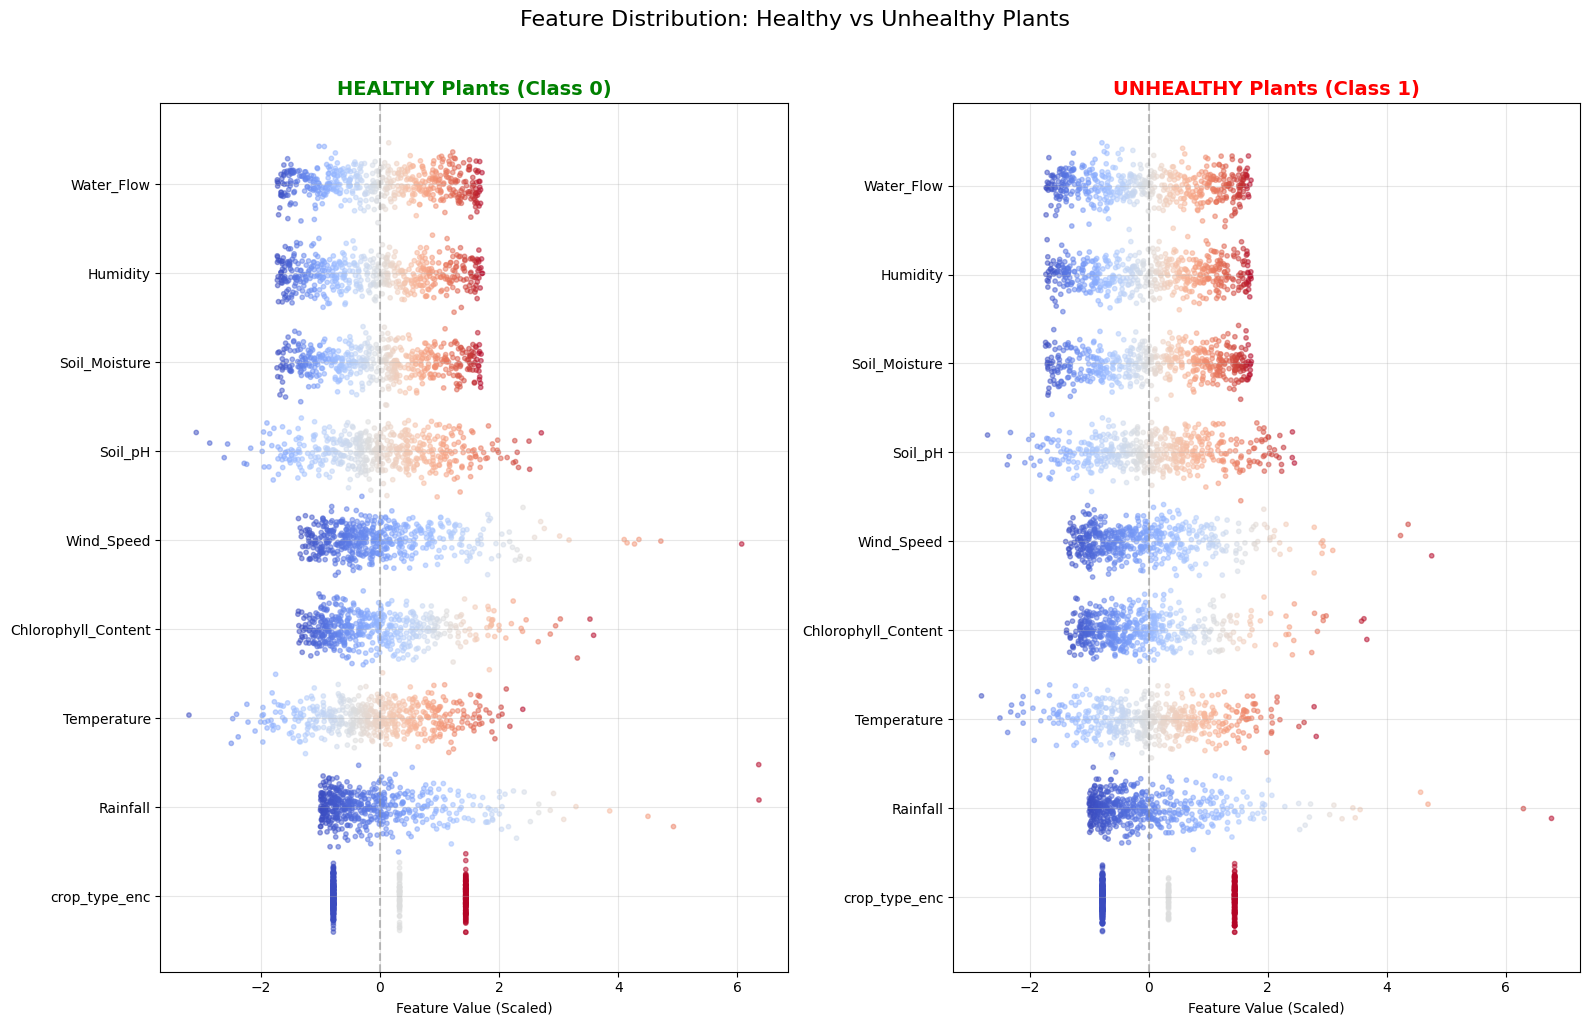


FEATURE IMPACT DIRECTION
Shows whether HIGH or LOW values indicate UNHEALTHY


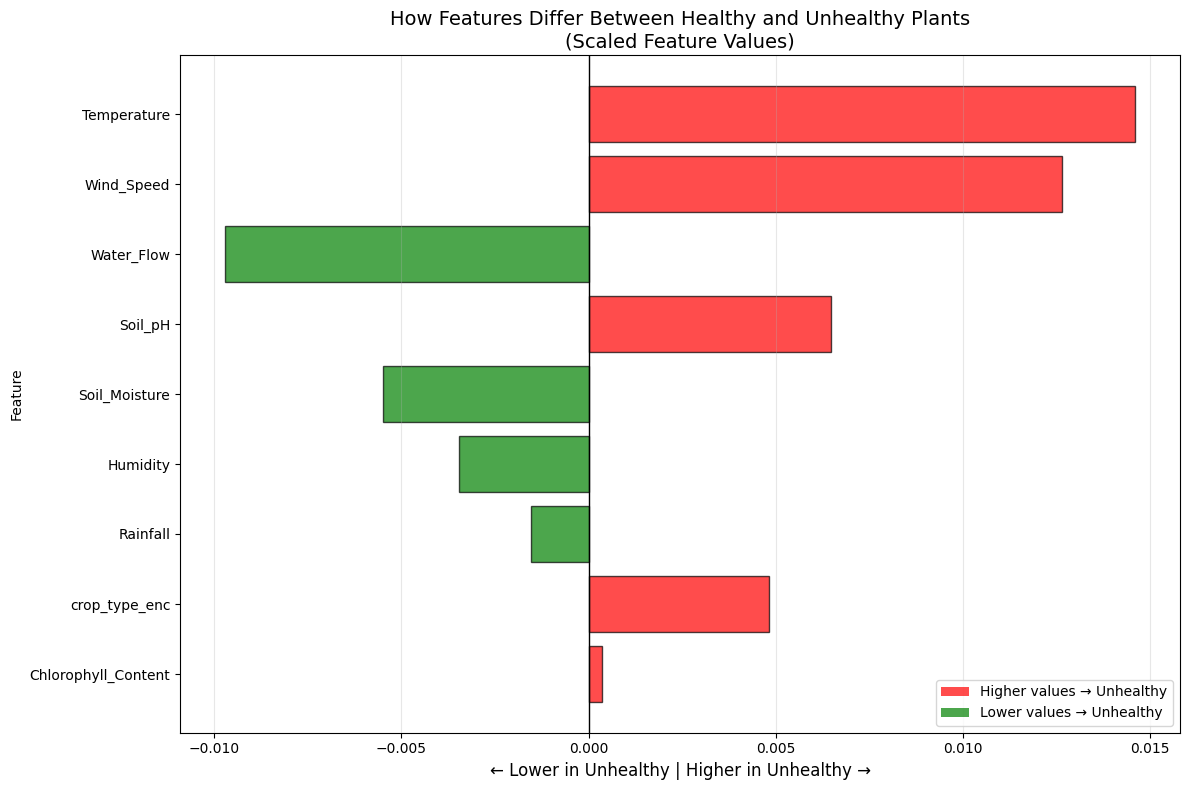


FEATURE IMPORTANCE WITH DIRECTION


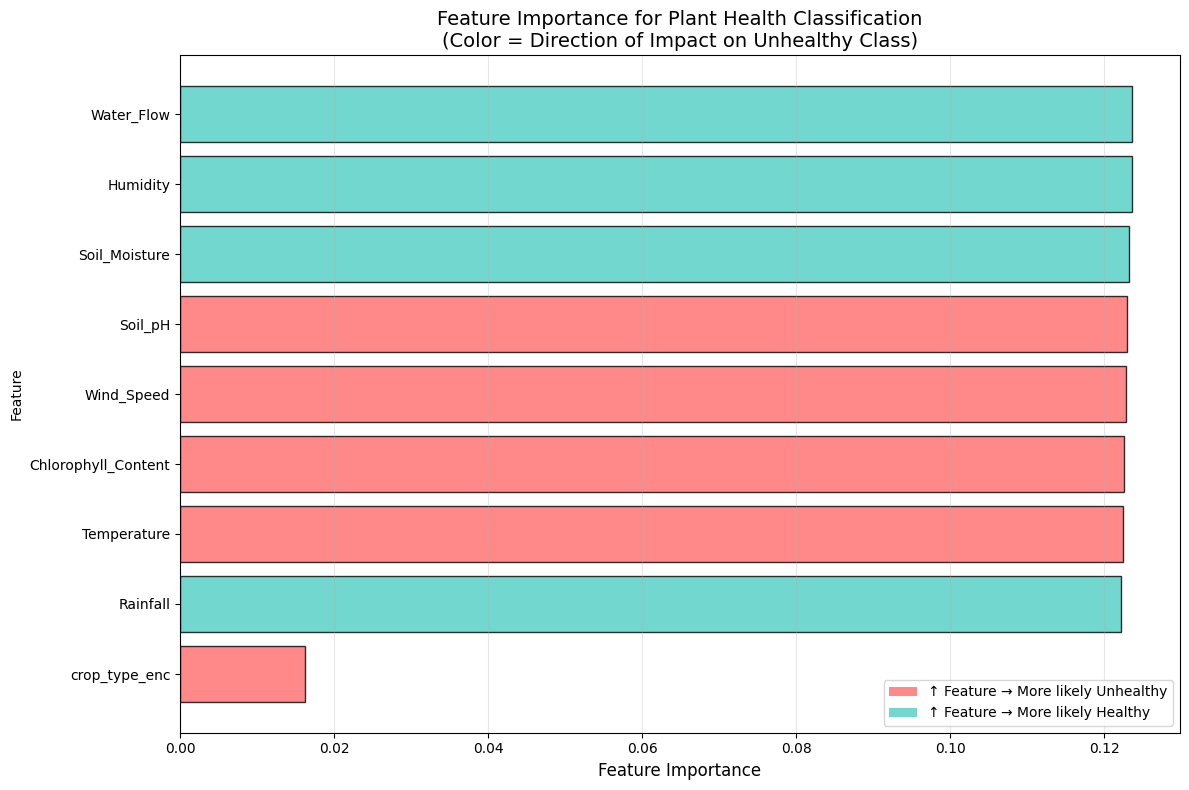


FEATURE IMPACT SUMMARY TABLE


C:\Users\evett\AppData\Local\Temp\ipykernel_19652\2598906997.py:180: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'color: red' if '↑' in str(x) else 'color: green', subset=['Direction']))


,Feature,Importance,Difference,Direction
7,Water_Flow,0.123700,-0.010000,↓ Lower = Unhealthy
2,Humidity,0.123600,-0.003000,↓ Lower = Unhealthy
5,Soil_Moisture,0.123300,-0.005000,↓ Lower = Unhealthy
6,Soil_pH,0.122900,0.006000,↑ Higher = Unhealthy
4,Wind_Speed,0.122800,0.013000,↑ Higher = Unhealthy
0,Chlorophyll_Content,0.122600,0.000000,↑ Higher = Unhealthy
1,Temperature,0.122500,0.015000,↑ Higher = Unhealthy
3,Rainfall,0.122300,-0.002000,↓ Lower = Unhealthy
8,crop_type_enc,0.016300,0.005000,↑ Higher = Unhealthy


In [ ]:
# SHAP-Style Feature Impact Summary (Memory-Efficient Alternative)
# Shows how each feature affects Healthy vs Unhealthy classification

print("=" * 80)
print("FEATURE IMPACT ON PLANT HEALTH CLASSIFICATION")
print("=" * 80)

# Get feature names and importance
feature_names = scaler.feature_names_in_.tolist()
importances = model.feature_importances_

# Create DataFrame with test data for analysis
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
X_test_df['Prediction'] = y_pred
X_test_df['Actual'] = y_test

# Get class labels
class_labels = le.classes_
print(f"\nClasses: {list(class_labels)}")

# Determine which class is "healthy" (usually class 0 or contains "healthy")
healthy_class = 0  # Adjust if needed
unhealthy_class = 1

# Calculate mean feature values for each class
healthy_mask = X_test_df['Actual'] == healthy_class
unhealthy_mask = X_test_df['Actual'] == unhealthy_class

healthy_means = X_test_df[healthy_mask][feature_names].mean()
unhealthy_means = X_test_df[unhealthy_mask][feature_names].mean()

# Calculate the difference (how much each feature differs between classes)
feature_diff = unhealthy_means - healthy_means

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Healthy_Mean': healthy_means.values,
    'Unhealthy_Mean': unhealthy_means.values,
    'Difference': feature_diff.values,
    'Impact': importances * np.abs(feature_diff.values)  # Weighted impact
}).sort_values('Impact', ascending=False)

# ============================================================
# PLOT 1: SHAP-Style Dot Plot (Feature Values by Class)
# ============================================================
print("\n" + "=" * 80)
print("SHAP-STYLE SUMMARY PLOT")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Sort features by importance
sorted_features = summary_df.sort_values('Importance', ascending=True)['Feature'].tolist()

# Left plot: Feature distribution for HEALTHY class
ax1 = axes[0]
for i, feat in enumerate(sorted_features):
    values = X_test_df[healthy_mask][feat].values
    # Sample if too many points
    if len(values) > 500:
        idx = np.random.choice(len(values), 500, replace=False)
        values = values[idx]
    # Add jitter
    y_jitter = np.random.normal(i, 0.15, len(values))
    # Color by value (normalized)
    colors = plt.cm.coolwarm((values - values.min()) / (values.max() - values.min() + 1e-10))
    ax1.scatter(values, y_jitter, c=colors, alpha=0.5, s=10)

ax1.set_yticks(range(len(sorted_features)))
ax1.set_yticklabels(sorted_features)
ax1.set_xlabel('Feature Value (Scaled)')
ax1.set_title(f'HEALTHY Plants (Class {class_labels[healthy_class]})', fontsize=14, fontweight='bold', color='green')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)

# Right plot: Feature distribution for UNHEALTHY class  
ax2 = axes[1]
for i, feat in enumerate(sorted_features):
    values = X_test_df[unhealthy_mask][feat].values
    if len(values) > 500:
        idx = np.random.choice(len(values), 500, replace=False)
        values = values[idx]
    y_jitter = np.random.normal(i, 0.15, len(values))
    colors = plt.cm.coolwarm((values - values.min()) / (values.max() - values.min() + 1e-10))
    ax2.scatter(values, y_jitter, c=colors, alpha=0.5, s=10)

ax2.set_yticks(range(len(sorted_features)))
ax2.set_yticklabels(sorted_features)
ax2.set_xlabel('Feature Value (Scaled)')
ax2.set_title(f'UNHEALTHY Plants (Class {class_labels[unhealthy_class]})', fontsize=14, fontweight='bold', color='red')
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)

plt.suptitle('Feature Distribution: Healthy vs Unhealthy Plants', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: Diverging Bar Chart (Feature Impact Direction)
# ============================================================
print("\n" + "=" * 80)
print("FEATURE IMPACT DIRECTION")
print("Shows whether HIGH or LOW values indicate UNHEALTHY")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 8))

# Sort by absolute impact
plot_df = summary_df.sort_values('Impact', ascending=True).tail(15)

colors = ['red' if d > 0 else 'green' for d in plot_df['Difference']]
bars = ax.barh(plot_df['Feature'], plot_df['Difference'], color=colors, alpha=0.7, edgecolor='black')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('← Lower in Unhealthy | Higher in Unhealthy →', fontsize=12)
ax.set_ylabel('Feature')
ax.set_title('How Features Differ Between Healthy and Unhealthy Plants\n(Scaled Feature Values)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='Higher values → Unhealthy'),
    Patch(facecolor='green', alpha=0.7, label='Lower values → Unhealthy')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: Combined Importance + Direction (SHAP-style bar)
# ============================================================
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE WITH DIRECTION")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 8))

plot_df = summary_df.sort_values('Importance', ascending=True)

# Color based on whether feature increase leads to unhealthy
colors = ['#FF6B6B' if d > 0 else '#4ECDC4' for d in plot_df['Difference']]

bars = ax.barh(plot_df['Feature'], plot_df['Importance'], color=colors, edgecolor='black', alpha=0.8)

ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_ylabel('Feature')
ax.set_title('Feature Importance for Plant Health Classification\n(Color = Direction of Impact on Unhealthy Class)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

# Add legend
legend_elements = [
    Patch(facecolor='#FF6B6B', alpha=0.8, label='↑ Feature → More likely Unhealthy'),
    Patch(facecolor='#4ECDC4', alpha=0.8, label='↑ Feature → More likely Healthy')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# ============================================================
# Summary Table
# ============================================================
print("\n" + "=" * 80)
print("FEATURE IMPACT SUMMARY TABLE")
print("=" * 80)

display_df = summary_df[['Feature', 'Importance', 'Difference']].copy()
display_df['Direction'] = display_df['Difference'].apply(
    lambda x: '↑ Higher = Unhealthy' if x > 0 else '↓ Lower = Unhealthy'
)
display_df = display_df.sort_values('Importance', ascending=False)
display_df['Importance'] = display_df['Importance'].round(4)
display_df['Difference'] = display_df['Difference'].round(3)

display(display_df.style.background_gradient(cmap='Reds', subset=['Importance'])
        .applymap(lambda x: 'color: red' if '↑' in str(x) else 'color: green', subset=['Direction']))

FEATURE IMPACT DIRECTION
Shows whether HIGH or LOW values indicate HEALTHY


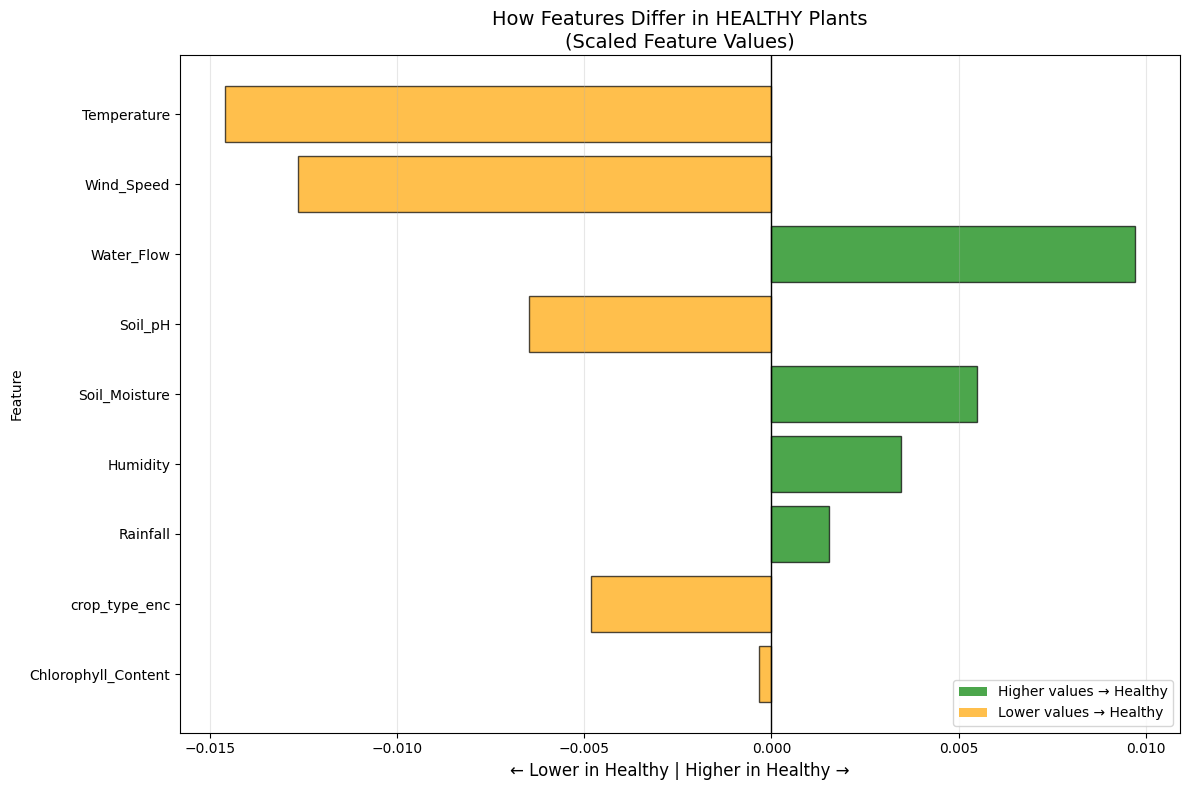

In [ ]:
# ============================================================
# PLOT: Feature Impact Direction for HEALTHY Plants
# ============================================================
print("=" * 80)
print("FEATURE IMPACT DIRECTION")
print("Shows whether HIGH or LOW values indicate HEALTHY")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 8))

# Sort by absolute impact (reuse summary_df from previous cell)
plot_df = summary_df.sort_values('Impact', ascending=True).tail(15)

# Reverse the difference to show healthy perspective
plot_df_healthy = plot_df.copy()
plot_df_healthy['Difference_Healthy'] = -plot_df_healthy['Difference']

colors = ['green' if d > 0 else 'orange' for d in plot_df_healthy['Difference_Healthy']]
bars = ax.barh(plot_df_healthy['Feature'], plot_df_healthy['Difference_Healthy'], color=colors, alpha=0.7, edgecolor='black')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('← Lower in Healthy | Higher in Healthy →', fontsize=12)
ax.set_ylabel('Feature')
ax.set_title('How Features Differ in HEALTHY Plants\n(Scaled Feature Values)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Higher values → Healthy'),
    Patch(facecolor='orange', alpha=0.7, label='Lower values → Healthy')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## Testing

In [8]:
model_ex = shap.TreeExplainer(model)

def get_stress_causes(sample_scaled):
    # Get SHAP values for this sample
    sv = model_ex.shap_values(sample_scaled, check_additivity=False)
    pred_class = model.predict(sample_scaled)[0]
    class_index = list(model.classes_).index(pred_class)
    
    # Handle different SHAP output formats
    if isinstance(sv, list):
        # Old format: list of arrays per class
        values = sv[class_index][0]
    elif len(sv.shape) == 3:
        # New format: 3D array (n_samples, n_features, n_classes)
        values = sv[0, :, class_index]
    else:
        # Binary or single output: 2D array (n_samples, n_features)
        values = sv[0]
    
    # Make a Series
    impact = pd.Series(values, index=scaler.feature_names_in_)
    
    # Pick top 3 by absolute impact
    top_causes = impact.abs().sort_values(ascending=False).head(3)
    return top_causes

def generate_recommendations(sample):
    causes = get_stress_causes(sample)
    return [f"Adjust {x}" for x in causes.index]

In [9]:
first_row = edge_df.drop(columns = ['Crop_Health_Label']).iloc[[0]].copy()

sample = scaler.transform(first_row)

prediction = model.predict(sample)

print("Plant Status:", prediction[0])

print("Top Causes:")
print(get_stress_causes(sample))

print("Recommendations:")
print(generate_recommendations(sample))

Plant Status: 1
Top Causes:
Soil_pH          0.004189
Temperature      0.003944
Soil_Moisture    0.003737
dtype: float64
Recommendations:
['Adjust Soil_pH', 'Adjust Temperature', 'Adjust Soil_Moisture']


In [15]:
# Reload the module to pick up changes
import importlib
import plant_health_checker
importlib.reload(plant_health_checker)
from plant_health_checker import check_plant_health

# Test multiple samples (pick random indices or specific ones)
sample_indices = [0, 10, 50, 100, 500]  # Change these to test different rows

print("=" * 80)
print("TESTING MULTIPLE SAMPLES")
print("=" * 80)

for idx in sample_indices:
    if idx < len(edge_df):
        # Get row as dictionary (excluding target)
        row_data = edge_df.drop(columns=['Crop_Health_Label']).iloc[idx].to_dict()
        actual_label = edge_df['Crop_Health_Label'].iloc[idx]
        
        # Check plant health
        result = check_plant_health(row_data)
        
        print(f"\n--- Sample {idx} ---")
        print(f"Actual Label: {actual_label}")
        print(f"Predicted:    {result['status']}")
        print(f"Confidence:   {result['confidence']}%")
        print(f"Correct:      {'✓' if result['status'] == actual_label else '✗'}")
        
        if not result['is_healthy']:
            print(f"Top Cause:    {result['top_cause']}")
    else:
        print(f"\nSample {idx}: Index out of range (max: {len(edge_df)-1})")

print("\n" + "=" * 80)

TESTING MULTIPLE SAMPLES

--- Sample 0 ---
Actual Label: 1
Predicted:    1
Confidence:   51.79%
Correct:      ✓
Top Cause:    Soil_pH

--- Sample 10 ---
Actual Label: 1
Predicted:    1
Confidence:   51.84%
Correct:      ✓
Top Cause:    Soil_Moisture

--- Sample 50 ---
Actual Label: 1
Predicted:    1
Confidence:   62.74%
Correct:      ✓
Top Cause:    Temperature

--- Sample 100 ---
Actual Label: 1
Predicted:    1
Confidence:   64.78%
Correct:      ✓
Top Cause:    Soil_Moisture

--- Sample 500 ---
Actual Label: 1
Predicted:    1
Confidence:   64.36%
Correct:      ✓
Top Cause:    Temperature

